# 📗 가설검정·회귀 — 회귀분석

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

지난 시간에는 "두 집단의 평균이 정말 다른가?" 처럼 **차이가 있는지**를 판정했습니다. 이번 시간에는 한 걸음 더 나아가 **한 변수로 다른 변수를 설명하고 예측**합니다. "자동차가 무거우면 연비가 얼마나 나빠질까?", "무게가 100파운드 늘면 연비는 몇 mpg 떨어질까?" 같은 물음에 **숫자로 답하는 도구**가 바로 **회귀분석(regression)** 입니다. 마지막에는 회귀 결과를 **믿어도 되는지 잔차로 점검**하고, 그것을 **의사결정 문장으로 옮기는** 데까지 갑니다.

## ⏪ 복습 — 지난 시간: 가설검정
지난 시간에는 **Pingouin 검정 한 줄로 판정**하는 법을 배웠습니다.
- 귀무가설(H₀)·대립가설(H₁)을 세우고, **p-value** 로 "우연으로 보기 어려운가"를 판단했습니다.
- `pg.ttest`(두 집단), `pg.anova`(여러 집단), `pg.chi2_independence`(범주형)로 검정했습니다.
- p-value 만으로는 부족해서 **효과크기**(Cohen's d 등)로 "얼마나 큰 차이인가"를 함께 봤습니다 — Pingouin 은 이 효과크기를 표에 기본 포함해 줬습니다.

> 이번 시간의 **회귀분석은 Pingouin 이 다루지 않습니다.** 그래서 검정은 Pingouin, **회귀는 `statsmodels`** 로 갑니다 (상관·잔차 Q-Q 처럼 pingouin 이 잘하는 부분은 계속 pingouin 을 씁니다).

그리고 그 전(기술통계) 시간에는 두 수치 변수가 **함께 움직이는 정도**를 **상관계수 r** 로 쟀습니다. 오늘은 그 **상관을 예측·설명으로 확장**합니다. 다리는 이렇게 놓입니다.

> **상관계수 r** (방향·강도) → **r² = 결정계수** (한 변수가 다른 변수의 분산을 몇 % 설명하나) → **회귀분석** (관계를 직선식으로 적어 **예측·설명**).

**오늘의 목표**
- [ ] **상관 r → r²(결정계수)** 로 이어지는 다리를 이해하고, 산점도에 추세선을 그린다.
- [ ] **단순 선형회귀**(`smf.ols`)로 회귀식을 구하고 `.summary()` 표(coef·P>|t|·R²)를 읽는다.
- [ ] **단순회귀의 R² 가 상관 r² 와 정확히 같다**는 것을 직접 확인한다.
- [ ] **다중 선형회귀**로 여러 변수를 함께 넣고, 계수를 **다른 변수를 고정했을 때의 효과**로 읽으며 모형끼리는 **Adj R²** 로 비교한다.
- [ ] **범주형 변수**를 더미(원-핫)로 바꿔 회귀에 넣고, 계수를 **기준 범주와의 차이**로 읽는다.
- [ ] **잔차 진단**(잔차 vs 적합값·잔차 Q-Q·Durbin-Watson)으로 회귀 결과를 믿어도 되는지 점검한다.
- [ ] 회귀 결과를 **의사결정 문장**으로 옮기고, 상관≠인과·외삽·유의≠실질 이라는 **한계**를 함께 말한다.

> 두 주제는 **참고 교안**으로 따로 묶었습니다 — 이 교안을 마친 뒤 이어서 보세요. **`참고_다중공선성.ipynb`**(독립변수끼리 얽힐 때: 진단 VIF·대처법) · **`참고_AB테스트.ipynb`**(비율 검정·Cohen's h·표본크기 산정).

In [2]:
# [제공 코드] 회귀분석·의사결정에 쓸 라이브러리와 한글 폰트를 준비합니다.
import warnings
warnings.filterwarnings('ignore')   # pingouin 의 사소한 경고를 숨겨 출력을 깔끔하게
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg               # 상관(pg.corr)·잔차 Q-Q(pg.qqplot) — 지난 시간에 이어 계속 사용
from scipy import stats             # 보조 통계 함수
import statsmodels.formula.api as smf          # 회귀분석 (smf.ols)
from statsmodels.stats.stattools import durbin_watson   # 잔차 독립성 지표


import platform

# 한글 폰트 — 실행 중인 OS 에 맞춰 자동 설정
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':          # macOS
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                        # Linux (Colab 등)
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(−) 부호 깨짐 방지
sns.set_theme(font=KOREAN_FONT, rc={'axes.unicode_minus': False})

---
## 데이터 살펴보기 — 자동차 연비(mpg)

오늘 회귀분석에 쓸 데이터는 자동차 연비 데이터 `mpg` 입니다. 새 데이터를 만나면 언제나 **먼저 눈으로 파악**하는 것이 첫걸음입니다 — 몇 행인지, 어떤 열이 있는지, 결측은 없는지.

- `mpg`: 연비(갤런당 마일, 클수록 좋음) — 우리가 **설명·예측하려는 대상(종속변수)**
- `weight`: 차량 무게(**파운드**, 1613~5140), `horsepower`: 마력, `displacement`: 배기량(입방인치) — **설명에 쓸 변수(독립변수)**
- `horsepower` 에는 결측(NA)이 6개 있습니다. **회귀는 쓰는 모든 변수에 값이 있어야** 하므로 여기서 **한 번만 정제해 398 → 392대**로 맞추고, 오늘 내내 그 데이터를 씁니다.

> **왜 처음에 한 번만 정제하나**: 모형끼리 비교하려면 **같은 데이터로 적합**해야 하기 때문입니다. R² 는 그 데이터의 **총변동을 나누는 값**이라, 표본이 달라지면 분모가 달라져 나란히 놓을 수 없습니다.

In [ ]:
raw = pd.read_csv('data/mpg.csv')
print('원본 크기(행, 열):', raw.shape)
print('\n[앞부분 5행]'); display(raw.head())
print('\n[구조: 열·자료형·결측]'); raw.info()
print('\n[수치형 요약]'); display(raw.describe())
print('\nhorsepower 결측 개수:', raw['horsepower'].isna().sum())

# 오늘 쓸 변수에 결측이 없는 행만 남긴다 — 이후 모든 모형이 같은 392대를 쓴다

# 한꺼번에 해당 컬럼들의 결측히 행을 제거
df = raw.dropna(subset=['mpg', 'weight', 'horsepower', 'displacement'])

# 특정 컬럼 1개의 결측치를 제거한 값을 시리즈로 반환
df['mpg'].dropna() 
df['weight'].dropna()
print('\n정제 후 크기:', df.shape, '(6대 제거)')

원본 크기(행, 열): (398, 9)

[앞부분 5행]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



[구조: 열·자료형·결측]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB

[수치형 요약]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000



horsepower 결측 개수: 6

정제 후 크기: (392, 9) (6대 제거)


---
# 1. 상관에서 회귀로 — r → r²(결정계수) → 예측

## 왜 필요할까요?
**상관계수 r** 은 두 수치 변수가 **같은 방향으로 얼마나 함께 움직이는지**를 −1~+1 로 알려 줍니다. 무게와 연비는 무거울수록 연비가 나빠지니 **음(−)의 상관**이 예상됩니다. 하지만 상관은 "방향과 강도"까지만 말해 줄 뿐, **"무게가 100파운드 늘면 연비가 정확히 몇 mpg 줄어드는가"** 는 답하지 못합니다. 그 답을 주는 것이 회귀입니다. 그 사이를 잇는 개념이 **r²(결정계수)** 입니다.

| 개념 | 무엇을 말해 주나 | 값의 범위 |
|---|---|---|
| 상관계수 **r** | 함께 움직이는 **방향(±)과 강도** | −1 ~ +1 |
| 결정계수 **r²** | 한 변수가 다른 변수의 **분산을 몇 % 설명**하나 | 0 ~ 1 (0~100%) |
| **회귀식** | 관계를 **직선(y = a + b·x)** 으로 적어 **예측·설명** | — |

**r² = r 을 제곱한 값**입니다. 예를 들어 r = −0.83 이면 r² ≈ 0.69 이고, 이는 "무게 하나만으로 연비의 흩어짐(분산)의 약 **69%** 를 설명할 수 있다"는 뜻입니다. 이 r² 가 곧 회귀에서 배울 **R²(결정계수)** 와 같은 값입니다.

> 🔧 **상관은 `pg.corr`**: 상관계수 r 은 **`pg.corr(x, y)`** 한 줄로 구합니다 — r·p-value 는 물론 **신뢰구간(CI95)·검정력**까지 한 표로 줍니다. (기존 대안: `scipy.stats.pearsonr` 은 r·p 만 줍니다.)

<img src="images/상관계수_비교.png" width="720"/>

,n,r,CI95,p_val,BF10,power
pearson,392,-0.832244,"[-0.86, -0.8]",6.015296e-102,1.579e+98,1.0


상관계수 r      = -0.8322
상관 유의확률 p = 6.02e-102  (0 에 매우 가까움 → 관계가 우연이 아니다)
95% 신뢰구간 CI95 = [-0.86 -0.8 ]  (pingouin 이 자동으로 함께 준다)
결정계수 r^2    = 0.6926  → 무게가 연비 분산의 약 69% 를 설명


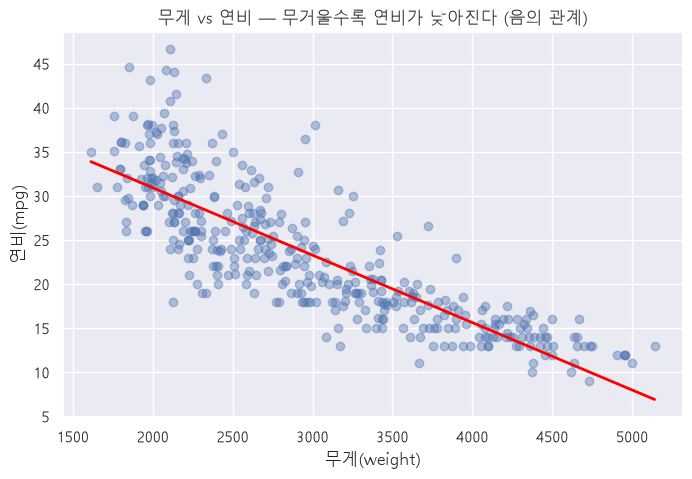

In [5]:
# 상관계수 r 과 결정계수 r^2 (무게 ~ 연비) — pg.corr 한 줄로 r·p·신뢰구간·검정력을 한 표로
corr_wm = pg.corr(df['weight'], df['mpg'])   # 🔧 대안: scipy.stats.pearsonr (r·p만)
display(corr_wm)

r = corr_wm['r'].iloc[0]
p_value = corr_wm['p_val'].iloc[0]
print('상관계수 r      = %.4f' % r)
print('상관 유의확률 p = %.3g  (0 에 매우 가까움 → 관계가 우연이 아니다)' % p_value)
print('95% 신뢰구간 CI95 =', corr_wm['CI95'].iloc[0], ' (pingouin 이 자동으로 함께 준다)')
print('결정계수 r^2    = %.4f  → 무게가 연비 분산의 약 %.0f%% 를 설명' % (r**2, r**2 * 100))

# 산점도 + 추세선 — sns.regplot 하나가 산점도와 직선을 함께 그려 준다
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='weight', y='mpg', ax=ax,
            scatter_kws={'alpha': 0.4},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=None)                     # ci=None 이면 신뢰띠 없이 직선만
ax.set_title('무게 vs 연비 — 무거울수록 연비가 낮아진다 (음의 관계)')
ax.set_xlabel('무게(weight)'); ax.set_ylabel('연비(mpg)')
plt.show()

### 📊 `pg.corr` 결과 표 읽는 법 — **딱 두 개만 보면 됩니다**

`pg.corr(x, y)` 는 **한 줄짜리 표**를 돌려줍니다(값 꺼내기: `결과['열이름'].iloc[0]`). 열이 여섯 개나 되지만 **결론은 `r` 과 `p_val` 두 개**로 납니다. 나머지는 참고이거나, 아예 안 봐도 됩니다.

> **표시 규칙** — **⭐ 꼭 봐야 할 것** · **○ 참고** · **✕ 이 단원에선 안 봐도 됨**

| | 열 | 뜻 | 이번 결과(무게~연비) |
|---|---|---|---|
| ⭐ | `r` | **상관계수** — 부호는 **방향**(+ 같이 늘어남 / − 반대), 절댓값은 **강도**(0.8↑ 매우 강함) | **−0.832** → 강한 음의 관계 |
| ⭐ | `p_val` | **p-value** — `< 0.05` 면 "상관이 0이다"를 기각(유의) | 6e−102 → 매우 유의 |
| ○ | `CI95` | r 의 95% 신뢰구간 — **0을 포함하지 않으면** 관계가 있다는 뜻(p 와 같은 이야기) | [−0.86, −0.80] |
| ○ | `n` | 계산에 쓰인 표본 수(결측이 빠졌는지 확인용) | 392 |
| ○ | `power` | **관측 검정력** — 관측된 r 을 참값으로 가정했을 때의 값. **p 가 정해지면 따라 정해지므로** 따로 볼 이유가 크지 않습니다 | 1.0 |
| ✕ | `BF10` | 베이즈 인자 — **이 단원에서 쓰지 않습니다. 무시하세요** | — |

> **읽기**: r = −0.832 → **무거울수록 연비가 낮고**(방향), 관계는 **매우 강합니다**(강도). p 는 0에 가까워 **유의**. r² = 0.693 → 무게 하나로 연비 흩어짐의 약 **69%** 를 설명합니다. 🔧 `scipy.stats.pearsonr` 로도 r·p 는 같은 값이 나옵니다(신뢰구간·검정력은 안 줌 — 어차피 ⭐가 아닙니다).

## 상관(관계)은 인과(원인)가 아니다

무게와 연비가 강하게 함께 움직인다고 해서 "무게가 연비를 **떨어뜨린 원인**"이라고 단정할 수는 없습니다. 회귀식도 마찬가지입니다 — **관계를 직선으로 요약**할 뿐, 그 자체로 인과를 증명하지 않습니다.

- **교란변수**가 숨어 있을 수 있습니다. 무거운 차는 대개 엔진도 크고 배기량도 큽니다. 겉으로 보이는 무게-연비 관계에 다른 변수의 영향이 섞여 있을 수 있습니다.
- **우연한 상관**도 흔합니다(아이스크림 판매량과 익사 사고 — 진짜 원인은 '여름').
- **인과를 말하려면** 무작위 통제 실험이 필요합니다. 이 이야기는 참고 교안 `참고_AB테스트.ipynb` 에서 이어집니다.

그래서 회귀 결과는 "무게가 1 늘면 연비가 b 만큼 **함께** 변하는 경향"으로 읽고, "무게가 연비를 b 만큼 **떨어뜨린다**"는 인과 단정은 조심합니다.

### 🖐️ 함께 따라하기 — 대기시간과 만족도의 상관·결정계수
데모는 **자동차 연비(mpg)** 로 봤습니다. 따라하기는 **다른 도메인 — 어느 고객센터의 상담 기록**(`callcenter_calls.csv`)으로 같은 분석을 연습합니다. 지난 단원에서 쓰던 그 데이터예요.

고객이 기다린 **대기시간(`대기시간_초`)** 과 **만족도** 의 관계를 봅니다. `pg.corr` 로 상관계수 r 을 꺼내고, r 을 제곱해 결정계수 r² 를 출력해 보세요.

> ⚠️ 이 셀에서 만드는 `cc` 를 **이후 따라하기에서 계속 씁니다** — 꼭 실행하고 넘어가세요.

In [7]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# ※ 데모는 '자동차 연비'였죠. 이번엔 다른 데이터(고객센터 상담 기록)로 연습합니다.
# 1) pd.read_csv 로 data/callcenter_calls.csv 를 읽어 cc 에 담고 head() 로 훑어본다
cc = pd.read_csv('./data/callcenter_calls.csv')
cc.head()

# 2) pg.corr(cc['대기시간_초'], cc['만족도']) 로 상관 표를 구해 r = [...]['r'].iloc[0] 로 꺼낸다
display(pg.corr(cc['대기시간_초'], cc['만족도']))

# 3) r 을 소수 4자리로 출력하고, r**2(결정계수)도 함께 출력한다
# 4) r 의 **부호**가 무엇을 뜻하는지 한 줄로 설명해 출력한다

,n,r,CI95,p_val,BF10,power
pearson,600,-0.675853,"[-0.72, -0.63]",2.761386e-81,4.862e+77,1.0


### ✅ 바로 확인 퀴즈
**1.** 결정계수 r² = 0.69 는 무슨 뜻인가요?

<details><summary>정답 보기</summary>

한 변수(무게)가 다른 변수(연비)의 **흩어짐(분산)의 약 69% 를 설명**한다는 뜻입니다. 나머지 31% 는 이 변수로는 설명되지 않는 부분(다른 요인·잡음)입니다. r² 는 상관계수 r 을 제곱한 값입니다.

</details>

**2.** 무게와 연비의 상관이 강하면 "무게가 연비를 떨어뜨린 원인"이라고 결론지어도 될까요?

<details><summary>정답 보기</summary>

안 됩니다. **상관은 인과가 아닙니다.** 배기량·마력 같은 교란변수가 숨어 있을 수 있고, 관계가 우연일 수도 있습니다. 인과를 말하려면 무작위 통제 실험이 필요합니다.

</details>

---
# 2. 단순 선형회귀 — 관계를 직선식으로 적는다

## 왜 필요할까요?
상관은 "함께 움직인다"까지만 말합니다. **단순 선형회귀(simple linear regression)** 는 그 관계를 **직선식**으로 적어 "무게가 1 늘면 연비가 얼마 변한다"를 숫자로 답하고, 새 자동차의 연비를 **예측**합니다.

$$ \text{연비} = a + b \times \text{무게} $$

- **b(기울기, coef)**: 무게가 **1 단위 늘 때 연비가 얼마나 변하는지**. 회귀의 핵심 해석값입니다.
- **a(절편, Intercept)**: 무게가 0 일 때의 이론상 연비(대개 해석 의미보다 계산상의 기준점).
- 회귀는 실제 점들과 직선의 **세로 거리(잔차)의 제곱합을 가장 작게** 만드는 직선을 찾습니다(최소제곱법).

`statsmodels` 의 `smf.ols('종속 ~ 독립', data=df).fit()` 한 줄로 이 직선을 구합니다. `ols` 는 최소제곱(Ordinary Least Squares)의 약자이고, `'mpg ~ weight'` 는 "weight 로 mpg 를 설명한다"는 뜻입니다.

> 🔧 **회귀는 `statsmodels`**: 지난 시간 검정은 `pingouin` 으로 했지만 **Pingouin 은 회귀분석을 다루지 않습니다.** 그래서 회귀는 계속 `statsmodels`(`smf.ols` + `.summary()`)로 하고, 상관(`pg.corr`)·잔차 Q-Q(`pg.qqplot`) 처럼 pingouin 이 잘하는 부분만 pingouin 을 씁니다.

In [8]:
# 단순 선형회귀: 무게(weight)로 연비(mpg)를 설명
model = smf.ols('mpg ~ weight', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     878.8
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          6.02e-102
Time:                        09:26:23   Log-Likelihood:                -1130.0
No. Observations:                 392   AIC:                             2264.
Df Residuals:                     390   BIC:                             2272.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.2165      0.799     57.867      0.0

연비 = -0.0076*무게 + 46.2165

## 📊 `.summary()` 표 읽는 법 — **딱 네 개만 보면 됩니다**

출력이 길어 처음엔 압도적입니다. 하지만 **표 세 개**(위=모형 전체 / 가운데=변수별 계수 / 아래=진단)가 붙어 있을 뿐이고, **결론을 만드는 값은 네 개뿐**입니다. 나머지 30여 개 숫자는 **지금 몰라도 됩니다** — 겁먹지 마세요.

> **표시 규칙** — **⭐ 꼭 봐야 할 것** · **○ 참고** · **✕ 이 단원에선 안 봐도 됨**

### ⭐ 꼭 봐야 할 네 개
| 어디에 | 이름 | 읽는 법 | 이번 결과(연비 ~ 무게) |
|---|---|---|---|
| 위 오른쪽 | `R-squared` | **설명력 R²**(0~1) — 종속변수 변동의 **몇 %를 모형이 설명**하나 | **0.693** → 연비 변동의 **69.3%** 설명 |
| 위 오른쪽 | `Adj. R-squared` | 변수 개수에 **벌점을 준 R²** — **변수 수가 다른 모형끼리 비교할 땐 이것**(3절) | 0.691 |
| 위 오른쪽 | `Prob (F-statistic)` | **모형 전체**가 의미 있나(H₀: 모든 기울기 = 0). **`< 0.05` 면 모형이 통째로 유의** | 6.02e−102 → 유의 |
| 가운데 | `coef` | **회귀계수** — 그 변수가 **1 늘 때 y의 평균 변화량**. **단위를 붙여 읽는 것이 핵심** | **−0.0076** → 무게 **1파운드** 늘면 연비 0.0076 mpg 감소(**100파운드면 약 0.76 mpg 감소**) |
| 가운데 | `P>\|t\|` | **그 계수의 p-value** — **`< 0.05` 면 그 변수의 효과가 유의** | 0.000 → 유의 |

(엄밀히는 다섯 칸이지만 `R²`·`Adj. R²` 는 한 짝입니다 — **"모형이 유의한가 · 얼마나 설명하나 · 각 변수의 계수와 유의성"** 이 전부입니다.)

### ○ 참고 — 필요할 때만
| 어디에 | 이름 | 읽는 법 | 이번 결과 |
|---|---|---|---|
| 가운데 | `[0.025  0.975]` | **계수의 95% 신뢰구간** — **0을 포함하면 유의하지 않다**(`P>\|t\|` 와 같은 이야기를 구간으로) | [−0.008, −0.007] → 0 미포함 → 유의 |
| 가운데 | `Intercept` 줄 | **절편 a**(모든 x가 0일 때의 y) — 해석보다 계산상의 기준점 | 46.22 |
| 위 왼쪽 | `No. Observations` | 실제로 쓰인 행 수 — **결측이 빠졌는지** 확인하는 자리 | 392 |
| 아래 | `Durbin-Watson` | 잔차의 **독립성**(0~4, 2 근처면 양호) | 0.808 — 2 에서 많이 멉니다. `mpg` 는 시계열이 아닌데 왜 그럴까요? **4절에서 답합니다** |

### ✕ 이 단원에선 안 봐도 되는 것 — **지금은 무시하세요**
`std err` · `t` (계수의 유의성은 **`P>\|t\|` 하나로 충분**합니다) · `F-statistic` 값 자체(판단은 **`Prob (F)`** 로) · `Cond. No.` (독립변수끼리 얼마나 얽혔는지 보는 값 — 참고 교안 `참고_다중공선성.ipynb` 에서 다룹니다) · `Omnibus` · `Prob(Omnibus)` · `Skew` · `Kurtosis` · `Jarque-Bera` (잔차 정규성은 4절에서 **Q-Q Plot 그림**으로 봅니다) · `AIC` · `BIC` · `Log-Likelihood` · `Df Residuals` · `Covariance Type` (**이 단원 범위 밖**).

> 출력에 숫자가 많다고 다 봐야 하는 게 아닙니다. **`statsmodels` 가 습관적으로 다 찍어 주는 것**일 뿐, **우리가 결론에 쓰는 건 ⭐ 네 개**입니다.

> ### 🧭 회귀 결과를 결론으로 바꾸는 순서 (⭐만 씁니다)
> 1. **모형이 유의한가?** → `Prob (F-statistic)` < 0.05
> 2. **얼마나 설명하나?** → `R-squared` (변수 수가 다른 모형끼리 비교하면 `Adj. R-squared`)
> 3. **각 변수는 어떤가?** → `coef` 의 **부호·크기(단위!)** + `P>\|t\|` 의 유의성
> 4. (필요하면) **믿어도 되나?** → 잔차 진단(4절)
>
> **주의**: `R²` 가 높다고 모형이 옳은 것도, `P>\|t\|` 가 작다고 효과가 **큰** 것도 아닙니다. "얼마나 큰가"는 **`coef` 의 실제 크기를 단위와 함께** 읽어야 알 수 있습니다(무게 100파운드 증가 → 연비 0.77 mpg 감소).

표를 눈으로 훑는 대신 ⭐ 값만 **속성으로 바로 꺼낼 수도 있습니다**: `model.params`(계수), `model.pvalues`(각 계수 p), `model.rsquared`(R²), `model.rsquared_adj`(조정 R²).

회귀식: 연비 = 46.217 + (-0.007647) x 무게
기울기 b = -0.007647 → 무게가 1 늘면 연비가 -0.007647 변한다(감소)
무게가 100파운드 늘면 연비는 약 -0.765 mpg 변한다
weight 계수의 p-value = 6.02e-102  (0.05 미만 → 유의)


0    30.921839
1    23.274497
2    15.627154
dtype: float64

  무게 2000 파운드 -> 예측 연비 30.9 mpg
  무게 3000 파운드 -> 예측 연비 23.3 mpg
  무게 4000 파운드 -> 예측 연비 15.6 mpg
실제 데이터의 무게 범위: 1613 ~ 5140 파운드
무게 6500 파운드 예측 = -3.5 mpg  <- 연비가 음수. 데이터에 없는 구간이라 믿을 수 없다
R^2 = 0.6926 → 무게가 연비 분산의 약 69% 설명


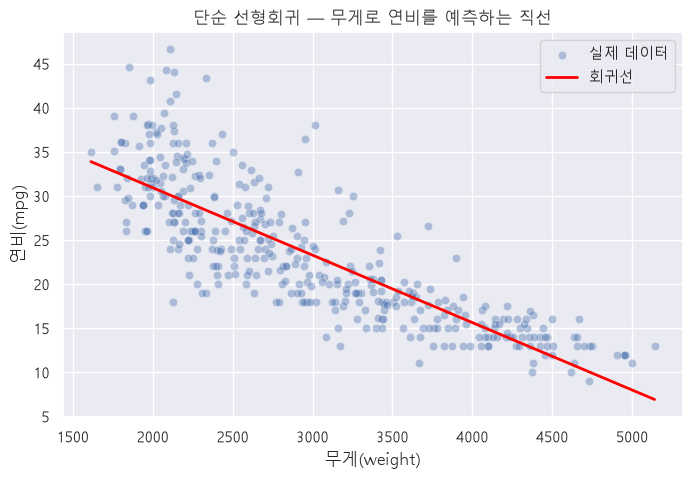

In [ ]:
# summary 표의 핵심 값을 속성으로 직접 꺼내기
intercept = model.params['Intercept']
slope = model.params['weight']
print('회귀식: 연비 = %.3f + (%.6f) x 무게' % (intercept, slope))
print('기울기 b = %.6f → 무게가 1 늘면 연비가 %.6f 변한다(감소)' % (slope, slope))
print('무게가 100파운드 늘면 연비는 약 %.3f mpg 변한다' % (slope * 100))
print('weight 계수의 p-value = %.3g  (0.05 미만 → 유의)' % model.pvalues['weight'])

# 새 차의 연비를 예측해 본다 — 회귀의 최종 목적
new_cars = pd.DataFrame({'weight': [2000, 3000, 4000]})
display(model.predict(new_cars))


fmt_pred = '  무게 %4d 파운드 -> 예측 연비 %.1f mpg'
for w, pred in zip(new_cars['weight'], model.predict(new_cars)):
    print(fmt_pred % (w, pred))


# 관측 범위를 벗어나면(외삽) 답이 무너진다
print('실제 데이터의 무게 범위: %d ~ %d 파운드' % (df['weight'].min(), df['weight'].max()))
fmt_extra = '무게 6500 파운드 예측 = %.1f mpg  <- 연비가 음수. 데이터에 없는 구간이라 믿을 수 없다'
print(fmt_extra % model.predict(pd.DataFrame({'weight': [6500]})).iloc[0])
print('R^2 = %.4f → 무게가 연비 분산의 약 %.0f%% 설명' % (model.rsquared, model.rsquared * 100))

# 회귀선을 산점도 위에 그려 본다 (model.predict 로 예측)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='weight', y='mpg', alpha=0.4, label='실제 데이터', ax=ax)
weight_line = np.linspace(df['weight'].min(), df['weight'].max(), 100)
pred_line = model.predict(pd.DataFrame({'weight': weight_line}))
sns.lineplot(x=weight_line, y=pred_line, color='red', linewidth=2, label='회귀선', ax=ax)
ax.set_title('단순 선형회귀 — 무게로 연비를 예측하는 직선')
ax.set_xlabel('무게(weight)'); ax.set_ylabel('연비(mpg)')
plt.show()

## 단순회귀의 R² = 상관 r² (같은 값을 다른 길로)

여기서 지난 상관 이야기와 정확히 만납니다. **독립변수가 하나뿐인 단순회귀에서는 모형의 R² 가 그 변수와 종속변수의 상관계수 r 을 제곱한 값(r²)과 정확히 같습니다.** 상관 → r² → 회귀 R² 로 이어지는 다리가 여기서 하나로 닫힙니다. 직접 확인해 봅시다.

In [11]:
# 상관 r 을 제곱한 값 vs 단순회귀 R^2 — 정확히 같은지 확인
r = pg.corr(df['weight'], df['mpg'])['r'].iloc[0]
print('상관계수 r        = %.6f' % r)
print('상관 r 의 제곱 r^2 = %.6f' % (r ** 2))
print('단순회귀 R^2       = %.6f' % model.rsquared)
print('두 값이 같은가? ', np.isclose(r ** 2, model.rsquared))

상관계수 r        = -0.832244
상관 r 의 제곱 r^2 = 0.692630
단순회귀 R^2       = 0.692630
두 값이 같은가?  True


### 🖐️ 함께 따라하기 — 대기시간으로 만족도를 설명하는 단순회귀
`대기시간_초` 로 `만족도` 를 설명하는 단순회귀를 적합해 봅니다. 기울기 계수·p-value·R² 를 출력한 뒤, 그 R² 가 앞에서 구한 상관 r² 와 같은지 확인해 보세요.

> 컬럼 이름이 한글이라 `smf.ols('만족도 ~ 대기시간_초', ...)` 처럼 그대로 써도 동작합니다. 다만 식(formula)에서 한글·언더스코어가 섞이면 헷갈리기 쉬우니, 아래처럼 **영문 별칭 열을 만들어** 쓰면 안전합니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) 회귀식에 쓰기 쉽도록 cc['wait'] = cc['대기시간_초'], cc['sat'] = cc['만족도'] 별칭 열을 만든다
cc['wait'] = cc['대기시간_초']
cc['sat'] = cc['만족도']

# 2) smf.ols('sat ~ wait', data=cc).fit() 로 model_wait 를 적합한다
model = smf.ols('sat ~ wait', data=cc).fit()

# 3) 절편·기울기·계수 p-value·R^2 를 출력한다
print(model.summary())
print('절편', model.params['Intercept'])
print('wait의 기울기 (계수)', model.params['wait'])
print('wait의 기울기의 p-value', model.pvalues['wait'])
print('R2', model.rsquared)

# 4) pg.corr 로 상관 r 을 구해 r**2 가 R^2 과 같은지 np.isclose 로 확인한다
# 5) 기울기에 100을 곱해 '대기시간 100초당 만족도 몇 점 변화'로 바꿔 해석 문장을 출력한다

new_data = pd.DataFrame({'wait':[100, 200, 300]})
display(model.predict(new_data))


                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     502.8
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.76e-81
Time:                        09:40:05   Log-Likelihood:                -504.04
No. Observations:                 600   AIC:                             1012.
Df Residuals:                     598   BIC:                             1021.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2537      0.031    137.856      0.0

0    3.610083
1    2.966416
2    2.322750
dtype: float64

In [ ]:

# 회귀식
# 만족도 =  -0.0064 * 대기시간 + 4.2537
print(-0.0064 * 100 + 4.2537)
print(-0.0064 * 200 + 4.2537)
print(-0.0064 * 300 + 4.2537)

new_data = pd.DataFrame({'wait':[100, 200, 300]})
display(model.predict(new_data))
# 0    3.610083
# 1    2.966416
# 2    2.322750
# dtype: float64



3.6137
2.9737
2.3337000000000003


### ✅ 바로 확인 퀴즈
**1.** `smf.ols('mpg ~ weight', data=df).fit()` 의 결과에서 `weight` 의 `coef`(기울기)가 음수라는 것은 무슨 뜻인가요?

<details><summary>정답 보기</summary>

무게가 **1 단위 늘어날 때 연비가 그만큼 줄어든다**(음의 관계)는 뜻입니다. 기울기 b 는 "독립변수 1 단위 변화에 대한 종속변수의 평균 변화량"입니다.

</details>

**2.** `.summary()` 에서 특정 변수의 효과가 **통계적으로 유의**한지 보려면 어느 값을 봐야 하나요?

<details><summary>정답 보기</summary>

그 변수 행의 **`P>|t|`(계수의 p-value)** 를 봅니다. 보통 0.05 미만이면 "그 변수의 효과가 유의하다"고 판단합니다. 속성으로는 `model.pvalues` 에서 꺼낼 수 있습니다.

</details>

**3.** 독립변수가 하나인 단순회귀에서 R² 는 무엇과 같나요?

<details><summary>정답 보기</summary>

그 독립변수와 종속변수의 **상관계수 r 을 제곱한 값(r²)** 과 정확히 같습니다. 상관 → r² → 회귀 R² 로 이어지는 다리가 단순회귀에서 하나로 만납니다.

</details>

---
# 3. 다중 선형회귀 — 여러 변수를 함께 넣는다

## 왜 필요할까요?
현실에서 연비는 무게 하나로만 정해지지 않습니다. 마력·배기량도 함께 영향을 줍니다. **다중 선형회귀(multiple linear regression)** 는 독립변수를 여러 개 넣어 함께 설명합니다.

$$ \text{연비} = a + b_1\,\text{무게} + b_2\,\text{마력} + b_3\,\text{배기량} $$

핵심은 **계수 해석이 바뀐다**는 점입니다. 다중회귀에서 `weight` 의 계수는 "**다른 변수(마력·배기량)를 고정한 채** 무게가 1 늘 때 연비의 평균 변화량"입니다. 즉 **다른 변수의 영향을 걷어낸** 순수한 무게의 효과입니다.

새로 볼 것은 **조정 결정계수(Adj R²)** 입니다. 변수를 많이 넣을수록 R² 는 무조건 커지는 성질이 있어, 이를 **변수 개수로 벌점을 매겨 보정**한 값입니다. 모형끼리 비교할 때는 R² 보다 **Adj R² 를 봅니다**.

결측은 맨 앞에서 이미 처리했으므로(392대), **2절의 단순회귀와 정확히 같은 데이터**로 적합합니다 — 그래야 두 모형의 R² 를 나란히 놓고 비교할 수 있습니다.

In [22]:
# 다중 선형회귀 (무게 + 마력 + 배기량 -> 연비) — 2절과 같은 392대
model_multi = smf.ols('mpg ~ weight + horsepower + displacement', data=df).fit()
print('분석 대상:', int(model_multi.nobs), '대 (2절 단순회귀와 같은 데이터)')
print(model_multi.summary())



분석 대상: 392 대 (2절 단순회귀와 같은 데이터)
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     312.0
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          5.10e-103
Time:                        09:44:48   Log-Likelihood:                -1120.6
No. Observations:                 392   AIC:                             2249.
Df Residuals:                     388   BIC:                             2265.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       4

## 결과 해석 — 배기량 계수는 왜 유의하지 않을까

위 표에서 흥미로운 일이 벌어집니다. 배기량(`displacement`)은 연비와 **혼자서는 강하게 상관**되는데, 다중회귀에서는 그 계수의 **p-value(`P>|t|`)가 0.05 보다 훨씬 큽니다**(유의하지 않음). 왜일까요?

**계수표를 방금 배운 사전대로 읽어 봅니다** — 긴 출력에서 **⭐ `coef` 와 `P>\|t\|` 두 열만** 보면 됩니다(신뢰구간은 ○ 참고 — 같은 이야기를 구간으로 말한 것).

| 변수 | `coef` | `P>\|t\|` | `[0.025  0.975]` | 판정 |
|---|---|---|---|---|
| `weight` | −0.0054 | 0.000 | [−0.007, −0.004] | 0을 **안** 포함 → **유의** |
| `horsepower` | −0.0417 | 0.001 | [−0.067, −0.016] | 0을 **안** 포함 → **유의** |
| `displacement` | −0.0058 | **0.381** | **[−0.019, 0.007]** | **0을 포함** → **유의하지 않음** |

배기량의 신뢰구간이 **0을 걸치고 있다**는 것은 "이 계수가 사실 0(효과 없음)일 가능성을 배제할 수 없다"는 뜻입니다 — `P>|t| = 0.381` 과 **정확히 같은 이야기**를 구간으로 말한 것입니다. 그리고 계수의 **부호·크기**로 보면 무게는 1 늘 때 연비 0.0054 감소, 마력은 1 늘 때 0.0417 감소입니다(마력 1이 무게 1보다 훨씬 큰 변화 — 단위가 다르니 크기 비교는 조심).

배기량·무게·마력이 **서로 거의 같은 정보를 담고 있기** 때문입니다(무거운 차는 대개 배기량·마력도 큼). 무게와 마력이 이미 연비를 설명해 버리면, 배기량이 **추가로 설명할 몫이 거의 남지 않습니다.**

그래서 다중회귀에서 **어떤 변수가 유의하지 않다고 해서 "그 변수는 관계가 없다"고 읽으면 안 됩니다.** 배기량은 혼자 넣으면 연비 변동의 65% 를 설명하는 강한 변수입니다. 함께 넣었을 때의 p-value 는 "**다른 변수들이 설명한 뒤에 추가로 설명할 몫**"에 대한 판정입니다.

> 이렇게 독립변수끼리 얽힌 상태를 **다중공선성(multicollinearity)** 이라고 부릅니다. **얼마나 얽혔는지 재는 법(VIF)과 처리하는 법**은 참고 교안 **`참고_다중공선성.ipynb`** 에서 이어집니다.

In [23]:
# 배기량을 '혼자' 넣으면 어떤가 — 함께 넣었을 때와 비교하기 위한 대조군
m_disp = smf.ols('mpg ~ displacement', data=df).fit()
fmt_solo = '배기량 단독: R^2 = %.4f, p = %.3g  <- 혼자서는 아주 강한 변수다'
print(fmt_solo % (m_disp.rsquared, m_disp.pvalues['displacement']))
print('함께 넣으면: p = %.4f  <- 유의하지 않다' % model_multi.pvalues['displacement'])

# R^2 는 커졌지만 Adj R^2 로 정직하게 비교 (2절 model 과 같은 392대라 그대로 나란히 놓을 수 있다)
print()
fmt = '  %s R^2 = %.4f, Adj R^2 = %.4f'
print(fmt % ('단순회귀(무게만)  ', model.rsquared, model.rsquared_adj))
print(fmt % ('다중회귀(3개 변수)', model_multi.rsquared, model_multi.rsquared_adj))

# Adj R^2 는 정말 벌점을 줄까 — 아무 의미 없는 난수 변수를 하나 넣어 본다
rng = np.random.default_rng(0)
df_noise = df.copy()
df_noise['noise'] = rng.normal(size=len(df_noise))
model_noise = smf.ols('mpg ~ weight + horsepower + displacement + noise', data=df_noise).fit()
print()
print(fmt % ('난수 변수 추가 전  ', model_multi.rsquared, model_multi.rsquared_adj))
print(fmt % ('난수 변수 추가 후  ', model_noise.rsquared, model_noise.rsquared_adj))
print('R^2 은 올랐는데 Adj R^2 는 내려갔다 -> 쓸모없는 변수에는 벌점이 붙는다.')

배기량 단독: R^2 = 0.6482, p = 1.66e-90  <- 혼자서는 아주 강한 변수다
함께 넣으면: p = 0.3813  <- 유의하지 않다

  단순회귀(무게만)   R^2 = 0.4568, Adj R^2 = 0.4559
  다중회귀(3개 변수) R^2 = 0.7070, Adj R^2 = 0.7047

  난수 변수 추가 전   R^2 = 0.7070, Adj R^2 = 0.7047
  난수 변수 추가 후   R^2 = 0.7070, Adj R^2 = 0.7040
R^2 은 올랐는데 Adj R^2 는 내려갔다 -> 쓸모없는 변수에는 벌점이 붙는다.


## 범주형 변수 넣기 — 국산·수입 같은 값은 숫자로 바꿔야 합니다

지금까지 넣은 변수는 전부 **수치형**(무게·마력·배기량)이었습니다. 그런데 연비에는 **제조국(`origin`)** 같은 **범주형** 변수도 영향을 줄 수 있습니다. 회귀는 숫자만 다루므로 `'usa'`·`'japan'` 같은 글자를 그대로 넣을 수 없습니다.

### 더미 변수(원-핫 인코딩)
범주를 **0과 1로 된 열**로 펼치는 것을 **더미 변수** 또는 **원-핫 인코딩**이라 합니다. `statsmodels` 는 식에 **`C(열이름)`** 이라고 쓰면 이 변환을 자동으로 해 줍니다.

| `origin` (원본) | `japan` 열 | `usa` 열 |
|---|---|---|
| `europe` (**기준**) | 0 | 0 |
| `japan` | 1 | 0 |
| `usa` | 0 | 1 |

> **범주가 3개인데 열은 2개**입니다. 하나를 **기준(reference)** 으로 빼기 때문입니다. 기준 범주는 모든 열이 0인 상태로 표현되므로 따로 열이 필요 없습니다.

### ⚠️ 기준을 빼지 않으면 — 더미 함정
범주 3개를 더미 3개로 **모두** 넣고 절편도 그대로 두면, 세 열의 합이 **언제나 1** 이라 **늘 1인 절편 열과 완전히 같아집니다.** 그러면 절편에 5를 더하고 세 더미에서 5씩 빼도 **예측값도 R² 도 똑같은** 조합이 무한히 많아져, **계수를 '기준과의 차이'로 읽을 수가 없습니다.**

에러가 나는 것이 아니라 **계수가 하나로 정해지지 않는 것**이 함정입니다(예측은 멀쩡합니다). 그래서 절편을 두는 대신 **기준 범주 하나를 빼고 k−1 개만** 넣습니다 — `C()` 가 이걸 알아서 해 줍니다.

In [ ]:
# 범주형 변수 origin 을 C() 로 넣기 — 더미(원-핫)는 statsmodels 가 자동 생성
model_cat = smf.ols('mpg ~ weight + C(origin)', data=df).fit()
print(model_cat.summary().tables[1])

print()
print('기준 범주는 europe (계수표에 없는 것이 기준입니다)')
for name in ['C(origin)[T.japan]', 'C(origin)[T.usa]']:
    print('  %-22s %+.4f  (europe 대비 연비 차이, p = %.4f)' %
          (name, model_cat.params[name], model_cat.pvalues[name]))

# 원산지를 넣으면 설명력이 오르나?
print()
print('무게만      R^2 = %.4f, Adj R^2 = %.4f' % (model.rsquared, model.rsquared_adj))
print('무게+원산지 R^2 = %.4f, Adj R^2 = %.4f' % (model_cat.rsquared, model_cat.rsquared_adj))

# 연비 = 1.35*일본 -0.97*미국 - 0.007*weight + 44.7
# 연비 = 1.35*1 - 0.97*0 -0.007*1000 + 44.7

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             44.7031      0.936     47.774      0.000      42.863      46.543
C(origin)[T.japan]     1.3562      0.711      1.908      0.057      -0.041       2.754
C(origin)[T.usa]      -0.9709      0.659     -1.474      0.141      -2.266       0.324
weight                -0.0070      0.000    -21.956      0.000      -0.008      -0.006

기준 범주는 europe (계수표에 없는 것이 기준입니다)
  C(origin)[T.japan]     +1.3562  (europe 대비 연비 차이, p = 0.0571)
  C(origin)[T.usa]       -0.9709  (europe 대비 연비 차이, p = 0.1413)

무게만      R^2 = 0.4568, Adj R^2 = 0.4559
무게+원산지 R^2 = 0.7020, Adj R^2 = 0.6997


**읽는 법**: `C(origin)[T.japan]` 의 계수는 "**무게가 같은 차끼리 비교했을 때**, 일본산이 유럽산(기준)보다 연비가 얼마나 높은가" 입니다. 범주형 계수는 언제나 **기준 범주와의 차이**로 읽습니다.

> ⚠️ **다만 이번 결과는 둘 다 유의하지 않습니다**(japan p = 0.057, usa p = 0.141). 방금 배운 규칙대로라면 "무게를 고정하면 제조국별 연비 차이가 있다고 말하기 어렵다" 가 정답입니다. 위 계수는 **범주형 계수를 읽는 법의 예시**로 보세요 — 계수 크기만 보고 "일본산이 더 좋다" 고 말하면 바로 앞 절에서 배운 것을 뒤집는 셈입니다.

### 순서가 있는 범주는 다르게 넣습니다
원-핫은 **순서가 없는(명목형)** 범주용입니다 — 제조국처럼 우열이 없는 경우죠. **저·중·고**나 **등급 C·B·A** 처럼 **순서가 있는(순서형)** 범주를 원-핫으로 펼치면 **그 순서 정보가 사라집니다.**

이때는 순서를 살려 정수로 매기는 **순서형 인코딩**을 씁니다 — `df['등급'].map({'저': 0, '중': 1, '고': 2})`.

> **다만 정수로 넣으면 회귀는 '저→중' 과 '중→고' 의 효과가 같다고 가정합니다.** 간격이 고르지 않다면 순서를 잃더라도 원-핫이 안전합니다.

### 🖐️ 함께 따라하기 — 범주형 변수 넣어 보기 (고객센터 채널)
데모는 자동차 **제조국**이었습니다. 따라하기는 고객센터의 **문의 채널**(전화·채팅·이메일)을 넣어 봅니다.

대기시간만으로 만족도를 설명하던 모형에 **채널**을 더하면 설명력이 얼마나 오르는지, 그리고 계수를 **어느 범주와의 차이**로 읽어야 하는지 확인해 보세요. 마지막으로 **더미를 3개 다 넣으면** 무슨 일이 벌어지는지도 직접 봅니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# ※ 데모는 자동차 제조국이었죠. 이번엔 고객센터 채널로 연습합니다.
# 1) smf.ols('sat ~ wait', data=cc) 와 smf.ols('sat ~ wait + C(채널)', data=cc) 를 각각 적합해
#    두 모형의 R^2 와 Adj R^2 를 나란히 출력한다
m_wait_only = smf.ols('sat ~ wait', data=cc).fit()
m_ch = smf.ols('sat ~ wait + C(채널)', data=cc).fit()
print(m_wait_only.summary())
print(m_ch.summary())

# 2) 계수표에서 C(채널)[T.전화] · C(채널)[T.채팅] 의 계수와 p-value 를 꺼내 출력한다
#    (계수표에 없는 범주가 '기준'이다 — 무엇이 기준인지 확인해 함께 출력한다)

# 3) pd.get_dummies(cc['채널']) 로 더미 3개를 만들어 전부 넣은 모형도 적합한다
#    R^2 와 예측값이 C() 모형과 같은지 np.isclose / np.allclose 로 확인하고,
#    절편이 어떻게 달라지는지 출력해 '더미 함정'을 눈으로 확인한다

                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     502.8
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           2.76e-81
Time:                        10:07:50   Log-Likelihood:                -504.04
No. Observations:                 600   AIC:                             1012.
Df Residuals:                     598   BIC:                             1021.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2537      0.031    137.856      0.0

In [ ]:
pd.get_dummies(cc['채널']) #원칙적인 원핫!
# 각 범주별 컬럼이 생성 (컬럼 3개)
# 이메일 
# 1,0,0

# 전화
# 0,1,0

# 채팅
# 0,0,1

pd.get_dummies(cc['채널'], drop_first=True) 
# 컬럼 2개
# 이메일 
# 0,0

# 전화
# 1,0

# 채팅
# 0,1





dummies = pd.get_dummies(cc['채널'])
cc_d = pd.concat([cc[['sat', 'wait']], dummies], axis=1) #axis=1 열방향으로 합치겠다
display(cc_d.head())
cc_d.columns = ['sat', 'wait', 'ch_email', 'ch_phone', 'ch_chat'] # 컬럼명 변경

m_all = smf.ols('sat ~ wait + ch_email + ch_phone + ch_chat', data=cc_d).fit()
print(m_all.summary())

m_all.predict(pd.DataFrame({'wait':[100], 'ch_email':[0], 'ch_phone':[1], 'ch_chat':[0]})) #3.950841

,sat,wait,이메일,전화,채팅
0,3.80,87.9,False,True,False
1,3.80,60.9,False,True,False
2,3.74,34.3,False,False,True
3,3.99,15.8,False,True,False
4,2.64,132.9,True,False,False


                            OLS Regression Results                            
Dep. Variable:                    sat   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     376.3
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          4.53e-137
Time:                        10:19:36   Log-Likelihood:                -368.29
No. Observations:                 600   AIC:                             744.6
Df Residuals:                     596   BIC:                             762.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            3.0368      0.021  

0    3.950841
dtype: float64

### 🖐️ 함께 따라하기 — 변수를 더 넣으면 항상 좋아질까 (Adj R²)
고객센터 데이터로 다중회귀를 해 봅니다. 먼저 **대기시간 + 상담시간 + 상담원경력** 세 변수로 적합하고, 거기에 **대기고객수**(대기 줄에 서 있던 인원)를 하나 더 넣어 비교합니다.

대기고객수는 대기시간과 사실상 같은 정보를 담고 있습니다(줄이 길면 오래 기다리죠). 이렇게 **겹치는 변수를 추가하면 무슨 일이 벌어지는지** 직접 확인해 보세요 — Adj R², 계수, p-value 세 가지를 모두 비교하는 것이 핵심입니다.

In [22]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) cc 에 영문 별칭 열을 더 만든다: talk(상담시간_분), exp(상담원경력_년), queue(대기고객수)
# 2) m3 = smf.ols('sat ~ wait + talk + exp', data=cc).fit() 로 3변수 모형을 적합한다
# 3) m4 = 여기에 + queue 를 더한 4변수 모형을 적합한다
# 4) 두 모형의 R^2 와 Adj R^2 를 나란히 출력해 비교한다 (Adj R^2 가 어떻게 되는지 주목)
# 5) wait 계수와 p-value 가 두 모형에서 어떻게 달라지는지, queue 자신의 p-value 는 얼마인지 출력한다

> 겹치는 변수를 넣으면 계수가 왜 이렇게 흔들리는지, **얼마나 얽혔는지 재는 법(VIF)과 처리하는 법**은 참고 교안 **`참고_다중공선성.ipynb`** 에서 이 데이터를 그대로 이어 다룹니다.

### ✅ 바로 확인 퀴즈
**1.** 다중회귀에서 `weight` 계수는 어떻게 해석하나요?

<details><summary>정답 보기</summary>

**다른 변수(마력·배기량)를 고정한 채** 무게가 1 늘 때 연비의 평균 변화량입니다. 즉 다른 변수의 영향을 걷어낸 무게 자체의 효과입니다.

</details>

**2.** 변수를 많이 넣은 모형과 적게 넣은 모형을 비교할 때 R² 대신 무엇을 봐야 하나요? 왜죠?

<details><summary>정답 보기</summary>

**조정 결정계수(Adj R²)** 를 봅니다. R² 는 쓸모없는 변수를 넣어도 무조건 커지지만, Adj R² 는 변수 개수에 벌점을 매겨 보정하므로 모형 간 공정한 비교가 됩니다.

</details>

**3.** `origin` 의 범주는 europe·japan·usa 세 개인데, 계수표에는 왜 두 줄만 나오나요? 그리고 `C(origin)[T.japan]` 의 계수는 무엇과의 차이인가요?

<details><summary>정답 보기</summary>

하나(`europe`)를 **기준 범주**로 빼고 **k−1 = 2개**만 넣기 때문입니다. 세 더미를 모두 넣으면 합이 늘 1 이라 절편과 겹쳐 계수가 하나로 정해지지 않습니다(더미 함정). 따라서 `C(origin)[T.japan]` 의 계수는 **기준인 europe 과의 연비 차이**로 읽습니다.

</details>

**4.** 다중회귀에서 어떤 변수의 `P>|t|` 가 0.38 로 나왔습니다. "이 변수는 종속변수와 관계가 없다"고 결론지어도 될까요?

<details><summary>정답 보기</summary>

안 됩니다. 배기량처럼 **혼자 넣으면 아주 강한 변수**도 겹치는 변수와 함께 넣으면 유의하지 않게 보입니다. "관계가 없다"가 아니라 "**다른 변수들이 설명한 뒤에 추가로 설명할 몫이 적다**"로 읽어야 합니다.

</details>

---
# 4. 회귀 진단 — 이 회귀 결과를 믿어도 될까

## 왜 필요할까요?
`smf.ols` 는 어떤 데이터에도 직선을 그어 줍니다. 하지만 그 직선이 **타당한지**는 별개 문제입니다. 선형회귀가 성립하려면 몇 가지 가정이 필요하고, 그 가정을 **잔차(residual)** 로 점검합니다.

> **잔차 = 실제값 − 예측값**. 회귀선이 각 점을 얼마나 빗맞혔는지를 나타냅니다. `model.resid`(잔차)와 `model.fittedvalues`(적합값=예측값)로 꺼냅니다.

선형회귀가 성립하려면 **네 가지 가정**이 필요합니다. 앞 글자를 따 **LINE** 으로 외웁니다 — **L**inearity(선형성) · **I**ndependence(독립성) · **N**ormality(정규성) · **E**qual variance(등분산성).

| 가정 | 뜻 | 점검 방법 |
|---|---|---|
| **선형성** | 관계가 실제로 직선에 가까움 | **잔차 vs 적합값 산점도** — 휘어진 곡선 무늬가 없어야 좋음 |
| **등분산성** | 잔차의 퍼짐이 어디서나 일정 | **잔차 vs 적합값 산점도** — 0 주변에 고르게 흩어져야 좋음(깔때기 모양이면 위반) |
| **정규성** | 잔차가 정규분포에 가까움 | **잔차 Q-Q Plot**(`pg.qqplot`) — 점들이 직선을 따라가야 좋음 |
| **독립성** | 잔차끼리 서로 상관 없음 | **Durbin-Watson**(`durbin_watson(잔차)`) — 2 근처면 독립적 |

> **가정은 넷인데 도구는 셋입니다** — **선형성과 등분산성은 `잔차 vs 적합값` 한 그림에서 함께** 읽습니다. 곡선 무늬가 보이면 선형성 위반, 퍼짐이 한쪽으로 커지면 등분산성 위반입니다.

> 🔧 잔차 Q-Q 는 **`pg.qqplot(resid, dist='norm', ax=ax)`** 으로 그립니다 — `scipy.stats.probplot` 과 같은 그림에 적합선·신뢰띠·R² 까지 얹어 줍니다. (회귀 자체는 계속 `statsmodels`.)

> **Q-Q Plot 은 모양으로 읽습니다** — 지난 시간 가정 점검에서 본 그 패턴 가이드가 잔차에도 그대로 적용됩니다.

<img src="images/QQ_Plot_패턴_가이드.png" width="720">

**좋은 잔차 그림**은 특별한 무늬가 없습니다(0 주변 랜덤 구름). **나쁜 신호**는 깔때기 모양(퍼짐이 커짐=이분산), 휘어진 곡선(관계가 직선이 아님), Q-Q 점이 양 끝에서 직선을 크게 벗어남(꼬리가 두꺼움) 등입니다.

잔차 개수: 392
잔차 평균 = -0.000000 (최소제곱 회귀에서 항상 0 에 가깝다)


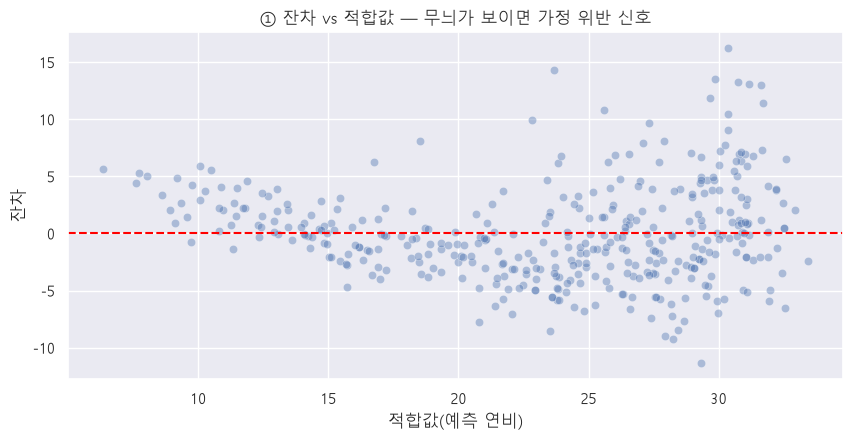

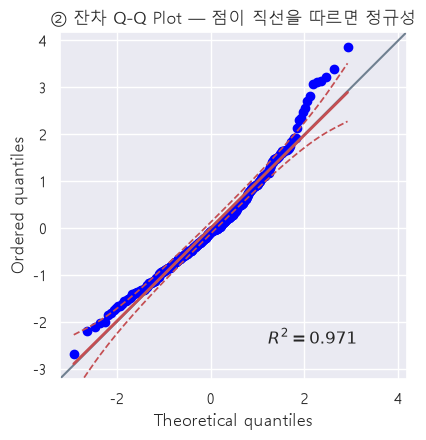

In [36]:
# 잔차와 적합값 꺼내기 (3변수 다중회귀 모형 기준)
residuals = model_multi.resid
fitted = model_multi.fittedvalues
print('잔차 개수:', len(residuals))
print('잔차 평균 = %.6f (최소제곱 회귀에서 항상 0 에 가깝다)' % residuals.mean())

# ① 잔차 vs 적합값 (선형성 + 등분산성을 한 그림에서)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('① 잔차 vs 적합값 — 무늬가 보이면 가정 위반 신호')
ax.set_xlabel('적합값(예측 연비)'); ax.set_ylabel('잔차')
plt.show()

# ② 잔차 Q-Q Plot (정규성) — pg.qqplot 으로 (🔧 대안: scipy.stats.probplot)
fig, ax = plt.subplots(figsize=(10, 4.5))
pg.qqplot(residuals, dist='norm', ax=ax)
ax.set_title('② 잔차 Q-Q Plot — 점이 직선을 따르면 정규성')
plt.show()

In [ ]:
# 그림을 눈으로만 보지 말고 숫자로도 확인한다 — 적합값을 5구간으로 나눠 잔차를 요약

band = pd.qcut(fitted, 5)

summary = pd.DataFrame({'적합값구간': band, '잔차': residuals}).groupby('적합값구간', observed=True)['잔차']
check = pd.DataFrame({'잔차 평균': summary.mean().round(2), '잔차 표준편차': summary.std().round(2)})
display(check)
print('평균이 + - - - + 로 휜다 -> 직선이 아니다(선형성 위반)')
fmt_sd = '표준편차가 %.2f 에서 %.2f 로 계속 커진다 -> 깔때기 모양(등분산성 위반)'
print(fmt_sd % (check['잔차 표준편차'].iloc[0], check['잔차 표준편차'].iloc[-1]))
print('잔차 정규성 p = %.2e -> 정규성도 기각' % pg.normality(residuals)['pval'].iloc[0])

,잔차 평균,잔차 표준편차
적합값구간,,
"(6.358, 16.785]",1.14,2.41
"(16.785, 23.195]",-1.73,2.81
"(23.195, 26.547]",-0.83,4.09
"(26.547, 29.578]",-0.94,4.55
"(29.578, 33.426]",2.32,5.25


평균이 + - - - + 로 휜다 -> 직선이 아니다(선형성 위반)
표준편차가 2.41 에서 5.25 로 계속 커진다 -> 깔때기 모양(등분산성 위반)
잔차 정규성 p = 6.80e-07 -> 정규성도 기각


### 이 모형의 진단 결과 — 네 가정이 모두 어긋납니다

그림과 표를 함께 읽으면 이렇습니다. **"좋은 그림" 의 예가 아니라 "나쁜 신호" 의 교과서적인 예**입니다.

| 가정 | 무엇이 보이나 | 판정 |
|---|---|---|
| **선형성** | 잔차 평균이 구간별로 +1.1 → −1.7 → −0.8 → −0.9 → +2.3 으로 **U자를 그림** | 위반 |
| **등분산성** | 잔차 표준편차가 **2.4 → 5.3** 으로 계속 커짐(오른쪽으로 벌어지는 깔때기) | 위반 |
| **정규성** | Q-Q 점들이 양 끝에서 직선을 벗어남, `pg.normality` p ≈ 7e−07 | 위반 |
| **독립성** | Durbin-Watson 0.86 (아래에서 확인) | 위반 |

> **그렇다고 이 회귀가 쓸모없다는 뜻은 아닙니다.** 계수의 방향과 크기는 여전히 참고할 만합니다. 다만 **p-value·신뢰구간을 그대로 믿기는 어렵고**, 예측 오차가 큰 차에서 더 크다는 것을 알고 써야 합니다. 어떻게 손보는지는 이 절 마지막의 **대처법 표**에서 이어집니다.

## ③ 독립성 — Durbin-Watson 통계량

**Durbin-Watson** 은 이웃한 잔차끼리 서로 상관(자기상관)되는지 재는 값입니다. $DW = \dfrac{\sum (e_t - e_{t-1})^2}{\sum e_t^2}$ 로 계산하며, **0~4 사이**의 값을 가집니다.

- **DW ≈ 2**: 잔차가 서로 독립적(좋음)
- **DW < 2**: 양의 자기상관(이웃 잔차가 비슷하게 움직임)
- **DW > 2**: 음의 자기상관

독립성 가정은 특히 **시간 순서가 있는 데이터**(매출 추이 등)에서 중요합니다. 지금 `mpg` 는 자동차별 단면 데이터인데도 DW 가 0.86 으로 2 에서 한참 멉니다. **행 순서에 숨은 구조가 있다는 신호**입니다 — 이 데이터는 **연식(`model_year`) 순으로 정렬**돼 있고, 연식은 연비에 큰 영향을 주는데 모형에 안 들어갔습니다. **빠뜨린 변수가 행 순서를 타고 잔차에 남은 것**입니다. 아래에서 연식을 넣으면 DW 가 어떻게 변하는지 직접 확인합니다.

In [39]:
# Durbin-Watson — statsmodels 함수 한 줄이면 된다
dw = durbin_watson(model_multi.resid)
print('Durbin-Watson = %.4f' % dw)
print('2 에서 멀다 -> 잔차가 서로 독립이 아니다.')

# 빠뜨린 변수(연식)를 넣으면 어떻게 되나
model_year = smf.ols('mpg ~ weight + horsepower + displacement + model_year', data=df).fit()
fmt_dw = '  %-22s DW = %.3f, R^2 = %.4f'
print(fmt_dw % ('연식 없이(3변수)', dw, model_multi.rsquared))
print(fmt_dw % ('연식을 넣으면(4변수)', durbin_watson(model_year.resid), model_year.rsquared))
print('DW 가 2 쪽으로 올라가고 설명력도 크게 늘었다 -> 독립성 위반의 정체는 빠뜨린 변수였다.')

Durbin-Watson = 0.8588
2 에서 멀다 -> 잔차가 서로 독립이 아니다.
  연식 없이(3변수)             DW = 0.859, R^2 = 0.7070
  연식을 넣으면(4변수)           DW = 1.229, R^2 = 0.8084
DW 가 2 쪽으로 올라가고 설명력도 크게 늘었다 -> 독립성 위반의 정체는 빠뜨린 변수였다.


## 가정이 깨졌으면 어떻게 하나 — 진단은 고치기 위한 것입니다

진단에서 문제를 찾는 것이 끝이 아닙니다. **무늬마다 대처법이 다릅니다.**

| 발견한 신호 | 깨진 가정 | 대처 |
|---|---|---|
| 휘어진 **곡선 무늬** | 선형성 | `y` 나 `x` 에 **로그**를 씌우거나 **제곱항**을 더해 휘는 관계를 담습니다 |
| **깔때기** 모양 | 등분산성 | 로그 변환이 여기에도 잘 듣습니다. 그래도 남으면 **이분산에 강한 표준오차**를 씁니다 |
| Q-Q 양 끝이 크게 휨 | 정규성 | **이상치부터** 확인합니다. 표본이 크면 어느 정도 비정규는 견딥니다 |
| DW 가 2 에서 멂 | 독립성 | **순서·시간 구조를 모형에 넣거나** 시계열 방법으로 갈아탑니다 |

> ⚠️ **변환한 모형의 R² 를 원래 모형과 나란히 두면 안 됩니다.** 종속변수가 바뀌면 **나누는 총변동 자체가 달라지기** 때문입니다. 비교하려면 예측을 원래 단위로 되돌린 뒤 같은 자로 재야 합니다.

구체적인 변환·로버스트 표준오차는 이 단원 범위를 넘습니다. 지금 필요한 것은 **무늬를 알아보고, 그것이 무엇을 뜻하며, 어느 방향으로 손봐야 하는지 아는 것**입니다.

### 🖐️ 함께 따라하기 — 내가 만든 모형의 잔차 진단
앞에서 직접 적합한 **`model_wait`(대기시간→만족도)** 의 잔차를 진단해 봅니다. **네 가정을 세 도구로** 확인합니다(선형성·등분산성은 첫 그림에서 함께).

1. **잔차 vs 적합값** 산점도 — 무늬(깔때기·곡선)가 있으면 등분산·선형성 위반 신호
2. **잔차의 정규성** — `pg.normality` 로 확인
3. **독립성** — `durbin_watson(잔차)` 로 확인(2 근처면 독립)

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# 1) plt.figure() 로 새 도화지를 열고,
#    sns.scatterplot(x=model_wait.fittedvalues, y=model_wait.resid, alpha=0.4) 로 잔차 vs 적합값을 그린다
# 2) plt.axhline(0, color='red', linestyle='--') 으로 0 기준선을 긋고 제목·축 라벨을 단 뒤 plt.show()
# 3) pg.qqplot(model_wait.resid, dist='norm', ax=ax) 로 Q-Q Plot 을 그리고,
#    pg.normality(model_wait.resid) 로 정규성 검정 p 와 판정도 함께 출력한다
# 4) durbin_watson(model_wait.resid) 로 Durbin-Watson 을 구해 출력한다

### ✅ 바로 확인 퀴즈
**1.** 잔차(residual)란 무엇인가요?

<details><summary>정답 보기</summary>

**실제값 − 예측값**입니다. 회귀선이 각 데이터 점을 얼마나 빗맞혔는지를 나타내며, `model.resid` 로 꺼냅니다.

</details>

**2.** '잔차 vs 적합값' 그림에서 점들이 오른쪽으로 갈수록 부채꼴로 퍼진다면 어떤 가정이 깨진 신호인가요?

<details><summary>정답 보기</summary>

**등분산성**이 깨진 신호(이분산)입니다. 잔차의 퍼짐이 예측값 크기에 따라 달라지면, 회귀의 표준오차·p-value 를 그대로 믿기 어려워집니다. 이상적으로는 0 주변에 무늬 없이 고르게 흩어져야 합니다.

</details>

**3.** Durbin-Watson 값이 2 근처라는 것은 무엇을 뜻하나요?

<details><summary>정답 보기</summary>

잔차끼리 <strong>자기상관이 거의 없다(독립적이다)</strong>는 뜻입니다. 2 에서 크게 벗어나면(특히 시계열 데이터에서) 잔차의 독립성 가정이 의심됩니다.

</details>

---
# 5. 종합 워크플로와 한계

## 데이터 기반 의사결정의 한 흐름
오늘 배운 도구들은 따로 노는 것이 아니라 **하나의 의사결정 흐름**으로 이어집니다.

1. **관계 파악**: 상관·산점도로 어떤 변수가 함께 움직이는지 본다(r, r²).
2. **모형화**: 회귀로 관계를 식으로 적고 계수·R²·p-value 로 설명·예측한다.
3. **효과크기**: "유의한가"뿐 아니라 "**얼마나 큰가**"를 함께 본다(계수 크기·r²·Cohen's d).
4. **신뢰구간**: 점추정에 불확실성의 폭을 붙여 말한다.
5. **의사결정**: 통계 결과 + 사업적 판단(비용·리스크)으로 실행 여부를 정한다.

## 반드시 기억할 한계
- **상관·회귀는 인과가 아니다**: 관찰 데이터의 회귀계수는 "함께 변하는 경향"이지 "원인"이 아닙니다. 인과를 말하려면 A/B 테스트 같은 **무작위 실험**이 필요합니다.
- **외삽(extrapolation)은 위험**: 회귀선은 관측 범위 안에서만 믿을 수 있습니다. 데이터에 없는 극단값을 예측에 넣으면 엉뚱한 답이 나올 수 있습니다.
- **통계적 유의 ≠ 실질적 유의**: 표본이 아주 크면 **사업적으로 사소한 작은 차이도 통계적으로 유의해질 수 있습니다.** 그래서 p-value 만 보지 말고 **효과크기와 신뢰구간**으로 실제 크기를 판단해야 합니다(숫자로 확인하는 예는 참고 교안 `참고_AB테스트.ipynb` 6절에 있습니다).

### ✅ 바로 확인 퀴즈
**1.** 표본이 매우 클 때 p-value 만 보고 의사결정하면 안 되는 이유는?

<details><summary>정답 보기</summary>

표본이 크면 **실질적으로 의미 없는 작은 차이도 통계적으로 유의**해질 수 있기 때문입니다. 따라서 p-value 와 함께 **효과크기(계수 크기·r²·Cohen's d)와 신뢰구간**으로 차이의 실제 크기를 판단해야 합니다.

</details>

**2.** 관찰 데이터로 적합한 회귀에서 '무게 계수가 음수'라는 결과를 인과로 말할 수 있나요?

<details><summary>정답 보기</summary>

없습니다. 관찰 데이터의 회귀계수는 "함께 변하는 경향"을 요약할 뿐 **인과를 증명하지 않습니다.** 인과 주장을 하려면 무작위 통제 실험(A/B 테스트)이 필요합니다.

</details>

---
## 🚀 응용 클론코딩 — 만족도 예측 모형 리포트

오늘 배운 것을 **한 흐름**으로 이어 봅시다: 상관 → 단순회귀 → 다중회귀 → 진단 → 결론.

**미션**: 고객센터장이 묻습니다. **"만족도를 올리려면 무엇부터 손대야 합니까?"** 회귀 모형으로 답하고, 그 답을 얼마나 믿을 수 있는지까지 함께 보고합니다.

> **표준화 계수란**: 단위가 다른 변수의 영향력을 비교하려고, 계수에 그 변수의 표준편차를 곱하고 종속변수의 표준편차로 나눈 값입니다. "그 변수가 **1 표준편차** 움직이면 y 는 **몇 표준편차** 움직이나" 가 되어 단위가 사라집니다. 초와 년처럼 자릿수가 다른 변수를 나란히 놓고 비교할 때 씁니다.

> 실무 회귀 리포트는 대개 이 다섯 줄로 끝납니다. **계수의 방향·크기·유의성**을 말하고, **모형이 얼마나 설명하는지**(R²)를 말하고, **가정이 지켜졌는지**(진단)를 말하는 것입니다.

In [ ]:
# 🖐️ 함께 따라하기 (아래 순서대로 직접 작성해 보세요)
# ※ 앞 따라하기에서 만든 cc 의 별칭 열(sat·wait·talk·exp)을 그대로 씁니다 — 그 셀을 먼저 실행하세요.
# 1) ['만족도','대기시간_초','상담시간_분','상담원경력_년'] 네 열의 상관행렬을 만들어 display 한다
# 2) 수치 세 변수에 범주형 채널까지 넣어 final 모형을 적합하고(C() 로 넣는다)
#    R^2, Adj R^2, f_pvalue 를 출력한다. 채널을 뺀 모형도 적합해 Adj R^2 를 비교한다
# 3) final.params 와 final.pvalues 를 한 표(DataFrame)로 묶어 display 한다
# 4) 표준화 계수(계수 x 변수 표준편차 / 만족도 표준편차)를 세 변수에 대해 출력해
#    단위가 다른 변수들의 영향력을 같은 잣대로 비교한다
# 5) 진단: 잔차 정규성(pg.normality)과 Durbin-Watson 을 출력한다
# 6) 위 근거로 '무엇부터 손대야 하는가'에 답하는 리포트 다섯 문장을 print 한다
#    (채널 계수는 '기준 범주와의 차이'로 읽어 함께 언급한다)
#    (마지막 문장에는 상관 != 인과 라는 한계를 반드시 넣는다)

### ✅ 바로 확인 퀴즈
**1.** 계수의 크기만 보고 "대기시간(-0.006)보다 상담원경력(+0.064)이 10배 중요하다"고 말해도 될까요?

<details><summary>정답 보기</summary>

**안 됩니다.** 두 변수의 **단위가 다릅니다**(초 vs 년). 대기시간은 수백 단위로 움직이고 경력은 한 자리 수로 움직이죠. 영향력을 비교하려면 **표준화 계수**처럼 같은 잣대로 바꿔야 합니다.

</details>

**2.** Adj R² 가 0.74 입니다. "만족도의 74%를 맞힐 수 있다"는 뜻인가요?

<details><summary>정답 보기</summary>

아닙니다. **만족도의 흩어짐(분산)의 약 74%를 이 모형이 설명한다**는 뜻입니다. 개별 고객의 만족도를 74% 확률로 맞힌다는 말이 아니에요. 나머지 26%는 이 모형이 담지 못한 요인입니다.

</details>

---
## 이번 강의 정리

| 개념 | 핵심 | 도구 |
|---|---|---|
| 상관 → 회귀 다리 | r(방향·강도) → r²(설명력 %) → 회귀(예측·설명) | `pg.corr`, `sns.regplot` |
| 단순 선형회귀 | 관계를 직선식으로; coef·P>\|t\|·R² 읽기 | `smf.ols('y ~ x').fit()`, `.summary()` |
| R² = r² | 단순회귀 R² 는 상관 r 의 제곱과 같다 | `model.rsquared`, `r**2` |
| 다중 선형회귀 | 여러 변수 동시 설명; 다른 변수 고정 해석; Adj R² | `smf.ols('y ~ x1 + x2')` |
| 범주형 변수 | 더미(원-핫)로 **k−1개**만 넣고 계수는 **기준 범주와의 차이**로 읽음; 순서형은 정수 매핑 | `C(열이름)`, `map()` |
| 유의하지 않은 계수 | 겹치는 변수와 함께 넣으면 강한 변수도 유의하지 않게 보인다 — "관계 없음"이 아니다 | `P>\|t\|`, 참고 교안 |
| 회귀 진단 (LINE 4가정) | 잔차 vs 적합값(**선형성·등분산성**)·Q-Q(정규성)·DW(독립성) | `model.resid`, `pg.qqplot`, `durbin_watson` |
| 결과의 한계 | 상관≠인과 · 외삽 위험 · 유의≠실질 — 결론에 함께 적는다 | 효과크기·신뢰구간 |

이제 여러분은 **상관을 회귀로 확장**해 예측·설명하고, 계수를 단위와 함께 읽으며, **결과를 믿어도 되는지 잔차로 점검**할 수 있습니다. 여기서 더 나아가는 두 주제는 참고 교안으로 이어집니다 — 독립변수끼리 얽혔을 때의 진단·대처는 **`참고_다중공선성.ipynb`**, 이 도구들을 비즈니스 의사결정에 쓰는 **A/B 테스트**는 **`참고_AB테스트.ipynb`** 입니다.

## ⏭️ 예고 — 다음 시간: 데이터 분석 종합 실습(MVP)
지금까지 배운 것들(기술통계·시각화·상관·추론·가설검정·회귀·A/B)을 하나로 묶어, **실제 데이터로 질문을 세우고 → 분석하고 → 결론과 의사결정을 내리는 종합 실습(MVP)** 을 진행합니다. 오늘의 회귀·의사결정 감각이 그 프로젝트의 마지막 조각이 됩니다.